# Hide-and-Seek Attribution: Weakly Supervised Segmentation of Vertebral Metastases in CT

This notebook demonstrates the weakly supervised vertebral metastasis segmentation method from:
> **Hide-and-Seek Attribution: Weakly Supervised Segmentation of Vertebral Metastases in CT**  
> Atad et al., 2025 · [arXiv:2512.06849](https://arxiv.org/abs/2512.06849)

Given a pretrained DAE and classifier, this notebook:
1. Generates a classifier-guided healthy edit of the input vertebra
2. Proposes candidate lesion regions from pixel-wise difference maps
3. Applies Hide-and-Seek Attribution to determine which candidates truly reflect malignancy
4. Outputs the final lytic/blastic segmentation

**Prerequisites:**
- DAE checkpoint at `../checkpoints/fxclass64_autoenc/last.ckpt` (auto-downloaded from Hugging Face Hub if missing)
- Classifier at `../checkpoints/classifier_lr.pkl` (included in repo)

## 0. Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import joblib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from skimage.measure import find_contours

import torch
import monai.transforms as T
import monai.data as md

from templates import *

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda:0


## 1. Load Pretrained DAE

The Diffusion Autoencoder (DAE) encodes images to a 512-dim semantic latent vector $z$
and a stochastic code $x_T$. Together these allow faithful reconstruction and controlled
semantic editing.

In [ ]:
conf = fxclass64_autoenc()
model = LitModel(conf)

ckpt_path = os.path.join('..', 'checkpoints', conf.name, 'last.ckpt')
if not os.path.exists(ckpt_path):
    from huggingface_hub import hf_hub_download
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    hf_hub_download(
        repo_id='matanatad/dae_verts',
        filename='last.ckpt',
        local_dir=os.path.dirname(ckpt_path),
    )

state = torch.load(ckpt_path, map_location='cpu')
model.load_state_dict(state['state_dict'], strict=False)
model.ema_model.eval()
model.ema_model.to(device)
print('DAE loaded successfully.')

## 2. Load Sample

We use a bundled anonymized CT vertebra patch (T10, malignant).  
To use your own data, replace the paths below with your own NIfTI files.

In [ ]:
CT_PATH  = '../data/sample/sample_ct.nii'
SEG_PATH = '../data/sample/sample_seg.nii'

transforms = T.Compose([
    T.LoadImaged(keys=['image', 'seg_msk'], ensure_channel_first=True),
    T.CenterSpatialCropd(keys=['image', 'seg_msk'], roi_size=(-1, -1, 1)),
    T.ScaleIntensityRangePercentilesd(keys='image', lower=0, upper=99.5, b_min=0, b_max=1),
    T.SqueezeDimd(keys=['image', 'seg_msk'], dim=3, update_meta=False),
])

sample_ds = md.Dataset(data=[{'image': CT_PATH, 'seg_msk': SEG_PATH}], transform=transforms)
batch = sample_ds[0]

orig_img = batch['image'].unsqueeze(0).to(device)   # (1, 1, H, W)
seg_msk  = batch['seg_msk'].unsqueeze(0).to(device) # (1, 1, H, W)

print(f'Image shape: {orig_img.shape}, range: [{orig_img.min():.3f}, {orig_img.max():.3f}]')

plt.figure(figsize=(4, 4))
plt.imshow(orig_img[0, 0].cpu(), cmap='gray')
plt.title('Input CT vertebra patch')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Verify Reconstruction Quality

We encode the image into its semantic latent $z$ and stochastic code $x_T$,
then reconstruct. The reconstruction should be near-identical to the input,
confirming the DAE has learned the image manifold.

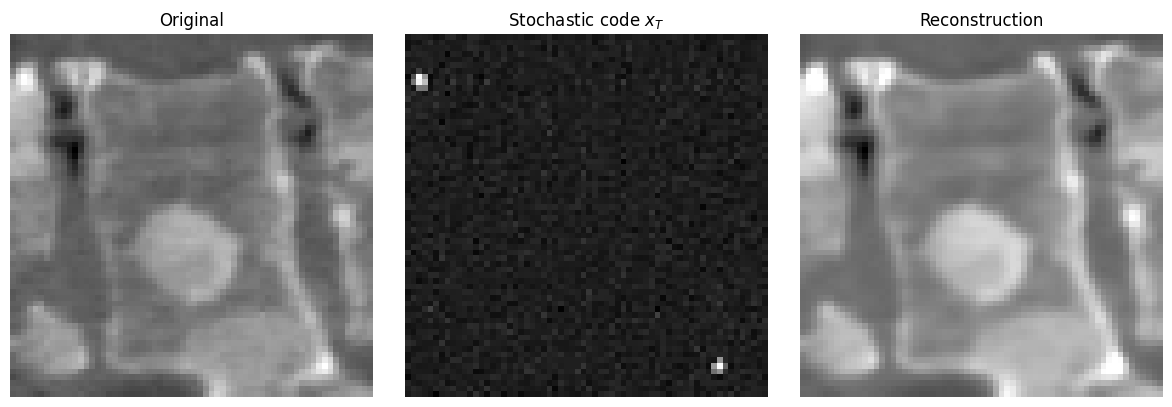

In [4]:
T_semantic  = 250  # DDIM reverse steps for stochastic encoding
T_stochastic = 100  # Diffusion steps for rendering

with torch.no_grad():
    cond  = model.encode(orig_img, ema=True)
    xT    = model.encode_stochastic(orig_img, cond, T=T_semantic, ema=True)
    recon = model.render(xT, cond, T=T_stochastic, ema=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_img[0, 0].cpu(), cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(xT[0, 0].cpu(),       cmap='gray'); axes[1].set_title('Stochastic code $x_T$')
axes[2].imshow(recon[0, 0].cpu(),    cmap='gray'); axes[2].set_title('Reconstruction')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Load Pretrained Classifier

A logistic regression classifier trained on latent vectors defines the
decision boundary between healthy ($z \to 0$) and malignant ($z \to 1$) vertebrae.

See `train_latent_classifier.ipynb` for how to train this classifier on your own data.

In [5]:
from sklearn.preprocessing import StandardScaler

lr_model   = joblib.load(os.path.join('..', 'checkpoints', 'classifier_lr.pkl'))
scaler_all = joblib.load(os.path.join('..', 'checkpoints', 'scaler.pkl'))

class TorchScalerWrapper:
    """Wraps sklearn StandardScaler to accept tensors and return tensors."""
    def __init__(self, scaler):
        self.scaler = scaler

    def transform(self, x, return_numpy=False):
        is_tensor = isinstance(x, torch.Tensor)
        x_np = x.detach().cpu().numpy() if is_tensor else x
        x_scaled = self.scaler.transform(x_np)
        if return_numpy or not is_tensor:
            return x_scaled
        return torch.tensor(x_scaled, dtype=x.dtype, device=x.device)

    def inverse_transform(self, x, return_numpy=False):
        is_tensor = isinstance(x, torch.Tensor)
        x_np = x.detach().cpu().numpy() if is_tensor else x
        x_inv = self.scaler.inverse_transform(x_np)
        if return_numpy or not is_tensor:
            return x_inv
        return torch.tensor(x_inv, dtype=x.dtype, device=x.device)

torch_scaler = TorchScalerWrapper(scaler_all)
print('Classifier and scaler loaded.')

Classifier and scaler loaded.


/home/matan/miniconda3/envs/dae2/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matan/miniconda3/envs/dae2/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 5. Generate Counterfactual Edit

We move the semantic latent $z$ along the classifier's decision hyperplane
until $P(\text{malignant}) \approx 0$. Rendering with the same stochastic
code $x_T$ produces a healthy counterfactual image where lesions are
removed while anatomy is preserved.

In [6]:
def get_dist_to_boundary(sample, class_model, torch_scaler):
    """Signed distance to the classifier hyperplane + P(malignant)."""
    w = class_model.coef_.reshape(-1)
    b = float(class_model.intercept_[0])
    sample_np = torch_scaler.transform(sample, return_numpy=True)
    w_norm = np.linalg.norm(w) + 1e-8
    signed_distance = (sample_np @ w + b) / w_norm
    logits = np.clip(sample_np @ w + b, -50, 50)
    p_tumor = 1.0 / (1.0 + np.exp(-logits))
    return signed_distance, p_tumor


def move_to_probability(sample, target_p, class_model, torch_scaler, device):
    """Move latent along the classifier normal so P(malignant) = target_p."""
    is_tensor = isinstance(sample, torch.Tensor)
    dist_before, prob_before = get_dist_to_boundary(sample, class_model, torch_scaler)
    w = class_model.coef_.reshape(-1)
    w_norm = np.linalg.norm(w) + 1e-8
    w_unit = w / w_norm
    dist_target = np.log(target_p / (1 - target_p)) / w_norm
    sample_np = torch_scaler.transform(sample, return_numpy=True)
    d_before = np.asarray(dist_before).reshape(-1, 1)
    moved_np = sample_np + (dist_target - d_before) * w_unit.reshape(1, -1)
    moved_orig = torch_scaler.inverse_transform(moved_np, return_numpy=True)
    if is_tensor:
        moved = torch.tensor(moved_orig, dtype=sample.dtype, device=device)
    else:
        moved = moved_orig
    dist_after, prob_after = get_dist_to_boundary(moved, class_model, torch_scaler)
    return moved, prob_before, prob_after

P(malignant) before edit: 0.9672
P(malignant) after  edit: 0.000010


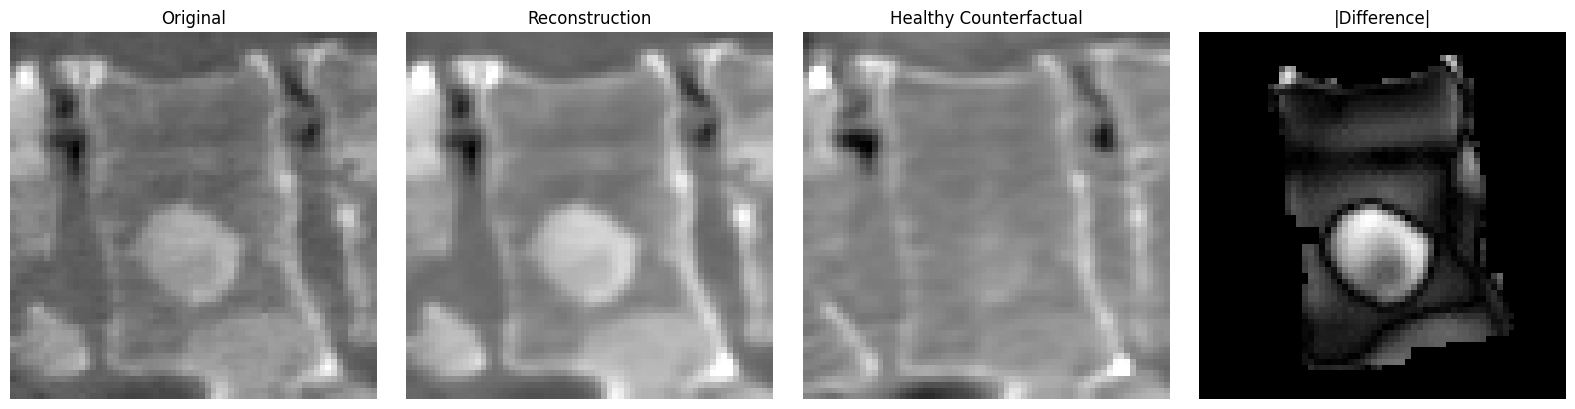

In [7]:
with torch.no_grad():
    target_p = 0.00001
    edit_cond, prob_before, prob_after = move_to_probability(
        cond, target_p, lr_model, torch_scaler, device
    )
    edit_img = model.render(xT, edit_cond, T=T_stochastic, ema=True)

malignant_prob = float(prob_before.item())
healthy_prob   = float(prob_after.item())
print(f'P(malignant) before edit: {malignant_prob:.4f}')
print(f'P(malignant) after  edit: {healthy_prob:.6f}')

diff = torch.abs(recon - edit_img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'Reconstruction', 'Healthy Counterfactual', '|Difference|']
imgs   = [orig_img, recon, edit_img, diff * seg_msk]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img[0, 0].cpu(), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Hide-and-Seek Attribution

The difference map reveals *where* the counterfactual differs, but not all
differences are due to lesions — some reflect imaging artifacts or co-founders.

For each candidate connected component we:
1. **Hide** all *other* candidates by replacing them with healthy intensities
2. **Harmonize** via a full DAE encode-decode cycle to fix boundary artifacts
3. **Re-classify** and measure $\Delta(M^k)$ = normalized change in malignancy score

Regions with high $\Delta$ are genuine lesion contributors.

In [8]:
def measure_contributions(mask_class, mask_all, orig_img, healthy_img,
                          class_model, encoder_model, malignant_prob, healthy_prob,
                          torch_scaler, device, tumor_type,
                          size_filter=5, T_sem=250, T_sto=100):
    """
    Hide-all-but-one with DAE harmonization.

    For each connected component in mask_class: keep it visible, replace all
    other candidates with healthy intensities, harmonize via DAE cycle,
    classify, measure delta.

    Returns list of dicts: region_msk, region_size, delta_cls_score, tumor_type
    """
    mask_cls_np = mask_class.squeeze().cpu().numpy().astype(np.uint8)
    mask_all_np = mask_all.squeeze().cpu().numpy().astype(np.uint8)
    orig_np     = orig_img.squeeze().cpu().numpy()
    healthy_np  = healthy_img.squeeze().cpu().numpy()

    labeled, n_components = scipy.ndimage.label(mask_cls_np)
    denom = malignant_prob - healthy_prob + 1e-8
    results = []

    for rid in range(1, n_components + 1):
        region_msk  = (labeled == rid)
        region_size = int(region_msk.sum())
        if region_size < size_filter:
            continue

        # Keep only this region from the original; replace others with healthy
        edited_np = orig_np.copy()
        others = mask_all_np.astype(bool) & ~region_msk
        edited_np[others] = healthy_np[others]

        edited_t = torch.tensor(edited_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        # DAE harmonization: encode → stochastic → render → re-encode
        with torch.no_grad():
            z   = encoder_model.encode(edited_t, ema=True)
            xT_ = encoder_model.encode_stochastic(edited_t, z, T=T_sem, ema=True)
            recon_ = encoder_model.render(xT_, z, T=T_sto, ema=True)
            z   = encoder_model.encode(recon_, ema=True)

        _, p = get_dist_to_boundary(z, class_model, torch_scaler)
        delta = (float(p.item()) - healthy_prob) / denom

        results.append({
            'region_msk':      region_msk,
            'region_size':     region_size,
            'delta_cls_score': delta,
            'tumor_type':      tumor_type,
        })

    return results

In [9]:
with torch.no_grad():
    # Lytic lesions brighten in counterfactual (edit > recon)
    # Blastic lesions darken in counterfactual (recon > edit)
    pos_diff = torch.clamp(edit_img - recon, min=0) * seg_msk  # lytic
    neg_diff = torch.clamp(recon - edit_img, min=0) * seg_msk  # blastic

    def median_mask(diff):
        vals = diff[diff > 0]
        if vals.numel() == 0:
            return torch.zeros_like(diff)
        return (diff > torch.quantile(vals, 0.5)).float()

    mask_pos = median_mask(pos_diff)           # lytic candidates
    mask_neg = median_mask(neg_diff)           # blastic candidates
    mask_all = (mask_pos + mask_neg) > 0

    print(f'Candidate pixels: {int(mask_pos.sum())} lytic, {int(mask_neg.sum())} blastic')

Candidate pixels: 514 lytic, 327 blastic


In [10]:
SIZE_FILTER = 5

contrib_blastic = measure_contributions(
    mask_neg, mask_all, recon, edit_img,
    lr_model, model, malignant_prob, healthy_prob,
    torch_scaler, device, 'blastic', SIZE_FILTER, T_semantic, T_stochastic,
)
contrib_lytic = measure_contributions(
    mask_pos, mask_all, recon, edit_img,
    lr_model, model, malignant_prob, healthy_prob,
    torch_scaler, device, 'lytic', SIZE_FILTER, T_semantic, T_stochastic,
)

contributions = contrib_blastic + contrib_lytic
print(f'{len(contrib_blastic)} blastic regions, {len(contrib_lytic)} lytic regions')
for c in contributions:
    print(f"  {c['tumor_type']:>8s}  size={c['region_size']:>4d}  delta={c['delta_cls_score']:.3f}")

5 blastic regions, 6 lytic regions
   blastic  size=   8  delta=0.055
   blastic  size=  12  delta=0.056
   blastic  size=  24  delta=0.049
   blastic  size= 218  delta=0.733
   blastic  size=  65  delta=0.067
     lytic  size= 180  delta=0.088
     lytic  size=   5  delta=0.052
     lytic  size=  17  delta=0.051
     lytic  size= 178  delta=0.113
     lytic  size=  81  delta=0.068
     lytic  size=  31  delta=0.055


## 7. Filter & Visualize

Keep regions with $\Delta \geq 0.5$ (contribute at least 50% of the malignant–healthy gap).

- **Red contours** = lytic (osteolytic) lesions
- **Blue contours** = blastic (sclerotic) lesions
- Labels show the normalized contribution score $\Delta$

1 regions after filtering (from 11 candidates)
   blastic  size= 218  delta=0.733


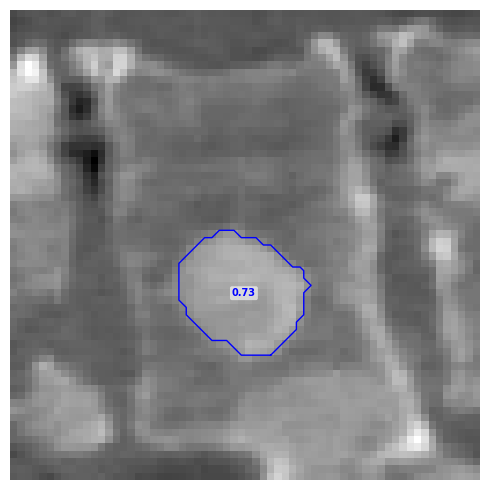

In [11]:
filtered = [c for c in contributions if c['delta_cls_score'] > 0.5]
print(f'{len(filtered)} regions after filtering (from {len(contributions)} candidates)')
for c in filtered:
    print(f"  {c['tumor_type']:>8s}  size={c['region_size']:>4d}  delta={c['delta_cls_score']:.3f}")

img_np = orig_img[0, 0].cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_np, cmap='gray')

if filtered:
    for c in filtered:
        color    = 'red' if c['tumor_type'] == 'lytic' else 'blue'
        contours = find_contours(c['region_msk'].astype(float), level=0.5)
        for i, contour in enumerate(contours):
            ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=1.0)
            if i == 0:
                cy, cx = contour.mean(axis=0)
                ax.text(cx, cy, f"{c['delta_cls_score']:.2f}",
                        color=color, fontsize=7, weight='bold', ha='center', va='center',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.2'))
else:
    ax.set_title('No lesion regions identified')

ax.axis('off')
plt.tight_layout()
plt.show()